In [43]:
# Cell 1 — Imports
import numpy as np
import pandas as pd
import xarray as xr
import sys
import matplotlib.pyplot as plt
from pathlib import Path
import glob

sys.path.append(str(Path("../src").resolve()))
from radar_lwc.preprocessing.chirps import combine_chirps
from radar_lwc.preprocessing.get_reflectivity import get_reflectivity
from radar_lwc.preprocessing.clean import drop_duplicate_times
from radar_lwc.preprocessing.align import align_to_reference_time
from radar_lwc.retrieval.kappa_liquid import kappa_liquid
from radar_lwc.retrieval.dielectric import epsilon_water_liebe1989
from radar_lwc.retrieval.zhu import retrieve_lwc_zhu

In [44]:
in_path = Path("../data/processed/aligned.nc")
ds = xr.open_dataset(in_path)
print(ds)

<xarray.Dataset> Size: 43MB
Dimensions:  (Time: 10441, range: 339)
Coordinates:
  * Time     (Time) datetime64[ns] 84kB 2023-09-28T07:00:04 ... 2023-09-28T14...
  * range    (range) float32 1kB 111.8 134.2 156.5 ... 1.194e+04 1.197e+04
    TAlt     (range) float32 1kB ...
Data variables:
    Ze_W     (Time, range) float32 14MB ...
    Ze_Ka    (Time, range) float32 14MB ...
    T_cloud  (Time, range) float32 14MB ...
Attributes:
    description:  Aligned W/Ka reflectivities + T field for LWC retrieval
    date:         20230928
    site:         Cabauw
    Ze_units:     dBZ
    created_by:   02_align.ipynb


=================================================

DWR HERE FIRST

=================================================

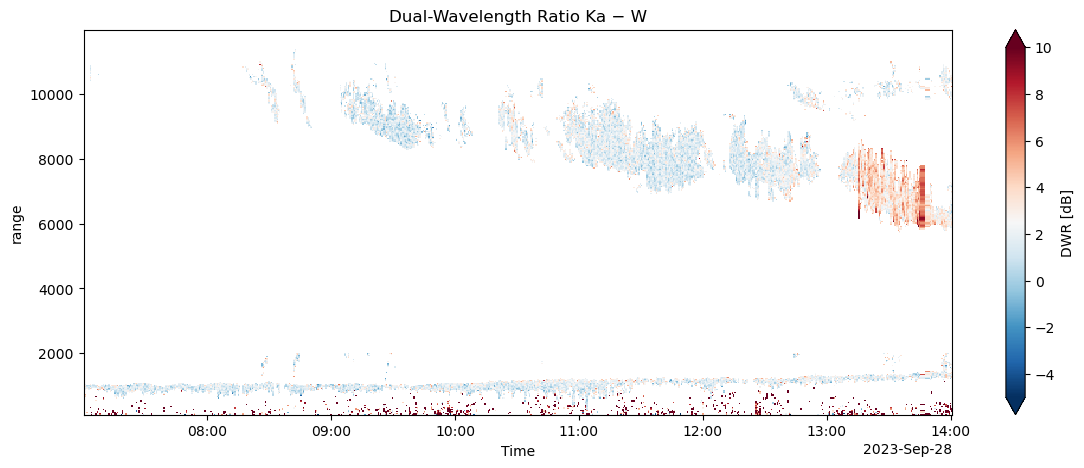

In [45]:
dwr = ds["Ze_Ka"]- ds["Ze_W"]      # in dB
dwr.name = "DWR"
dwr.attrs["units"] = "dB"
fig, ax = plt.subplots(figsize=(14, 5))
dwr.plot(x="Time", y="range", cmap="RdBu_r", vmin=-5, vmax=10, ax=ax, cbar_kwargs={"label": "DWR [dB]"})
ax.set_title("Dual-Wavelength Ratio Ka − W")
plt.show()

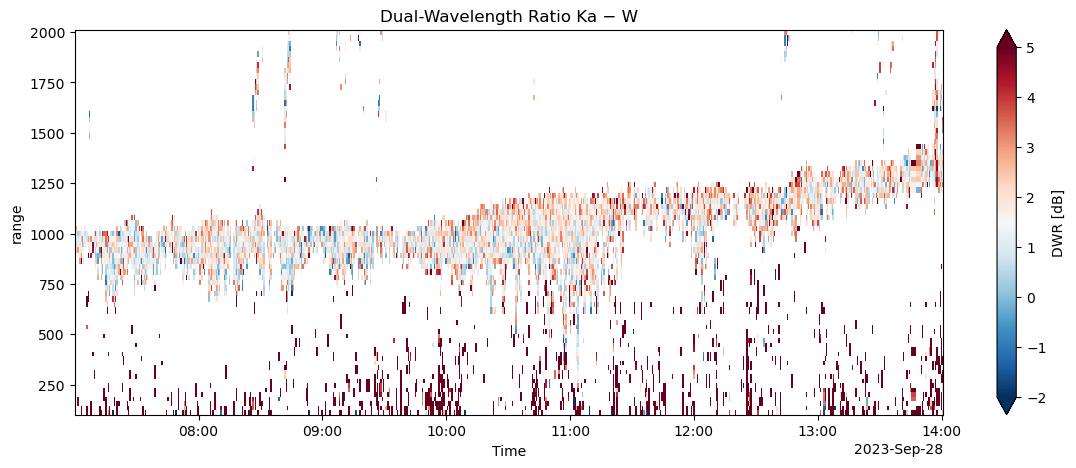

In [46]:
dwr_2km = dwr.sel(range=slice(0, 2000))

fig, ax = plt.subplots(figsize=(14, 5))

dwr_2km.plot(
    x="Time",
    y="range",
    cmap="RdBu_r",
    vmin=-2,
    vmax=5,
    ax=ax,
    cbar_kwargs={"label": "DWR [dB]"}
)

ax.set_title("Dual-Wavelength Ratio Ka − W")
plt.show()

In [ ]:
# 1. Confirm DWR is in dB
print("DWR stats (cloud only):")
cloud_dwr = dwr.where(dwr > -5).where(dwr < 20)  # rough cloud filter
print(f"  median: {float(cloud_dwr.median()):.2f}")
print(f"  90th pct: {float(cloud_dwr.quantile(0.9)):.2f}")       # 90% of DWR are below 4.49dB
print(f"  range: {float(cloud_dwr.min()):.2f} to {float(cloud_dwr.max()):.2f}")

# 2. Confirm range axis
print(f"\nRange axis: first={float(dwr['range'][0]):.1f} m, last={float(dwr['range'][-1]):.1f} m")
print(f"Δh = {float(dwr['range'][1] - dwr['range'][0]):.1f} m")

# 3. Check kappa
print(f"\nkappa_W: {float(kappa_w.mean()):.3f} dB/km/(g/m³)")
print(f"kappa_Ka: {float(kappa_ka.mean()):.3f} dB/km/(g/m³)")
print(f"Δκ: {float((kappa_w - kappa_ka).mean()):.3f}")


DWR stats (cloud only):
  median: 2.00
  90th pct: 4.49
  range: -5.00 to 20.00

Range axis: first=111.8 m, last=11974.8 m
Δh = 22.4 m

kappa_W: 4.290 dB/km/(g/m³)
kappa_Ka: 0.800 dB/km/(g/m³)
Δκ: 3.490


In [50]:
print(float(dwr.min()))
print(float(dwr.max()))

-15.36152458190918
52.93231964111328


===============================

KAPPA AND ALPHA CALCULATION AND PLACEHOLDERS FOR NOW

====================================

In [51]:
eps35 = epsilon_water_liebe1989(35.0, 10.0)
eps94 = epsilon_water_liebe1989(94.0, 10.0)

print(eps35)
print(eps94)

(14.529118996612565-25.186642123507625j)
(6.8077640928799354-10.716147683385891j)


In [52]:
print(kappa_liquid(35.0, 10.0))
print(kappa_liquid(94.0, 10.0))

0.7956729460013171
4.288582543382424


In [54]:
alpha_w = xr.DataArray(
    np.full_like(dwr.values, 0.65),
    dims=dwr.dims,
    coords=dwr.coords,
    name="alpha_W",
)

alpha_ka = xr.DataArray(
    np.full_like(dwr.values, 0.14),
    dims=dwr.dims,
    coords=dwr.coords,
    name="alpha_Ka",
)

In [55]:
kappa_w = xr.DataArray(
    np.full_like(dwr.values, 4.29),
    dims=dwr.dims,
    coords=dwr.coords,
    name="kappa_W",
)

kappa_ka = xr.DataArray(
    np.full_like(dwr.values, 0.80),
    dims=dwr.dims,
    coords=dwr.coords,
    name="kappa_Ka",
)

CLOUD MASK PLACEHOLDER AND FIRST TRY TO IMPLEMENT EARLY VERSION

In [56]:
# cloud_mask = xr.DataArray(
#     np.ones_like(dwr.values, dtype=bool),
#     dims=dwr.dims,
#     coords=dwr.coords,
#     name="cloud_mask",
# )

In [ ]:
# %% Real cloud mask (replace the all-True placeholder)
# Cloud = both radars see a return above noise floor.
# -40 dBZ is a conservative Ka-band cloud detection threshold.
cloud_mask = (
    ds["Ze_Ka"].notnull()
    & ds["Ze_W"].notnull()
    & (ds["Ze_Ka"] > -40)
    & (ds["Ze_W"] > -40)
)
cloud_mask.name = "cloud_mask"
print(f"Cloud fraction (full column): {float(cloud_mask.mean()):.2%}")     # .2: two digits after decimal and %: that in percentage; .mean of Boolean array takes true as 1 and false as 0. So True divided by all Booleans in Array 

# 2 km version to match your existing workflow
cloud_mask_2km = cloud_mask.sel(range=slice(0, 2000))                  #.sel(range=slice(0, 2000)) only takes first 2 km
print(f"Cloud fraction (0–2 km):     {float(cloud_mask_2km.mean()):.2%}")


Cloud fraction (full column): 9.04%
Cloud fraction (0–2 km):     13.55%


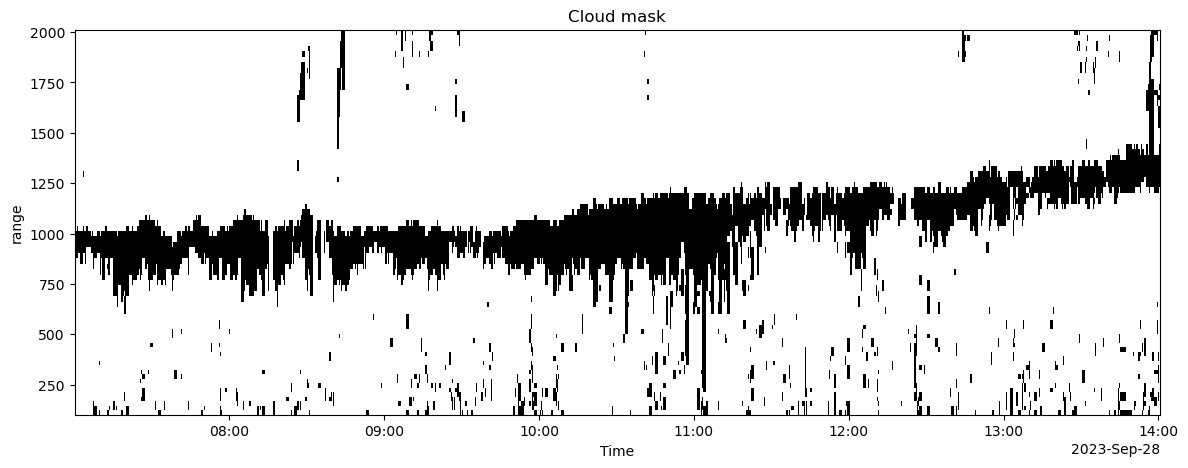

In [58]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 5))

cloud_mask.sel(range=slice(0, 2000)).plot(
    x="Time",
    y="range",
    cmap="Greys",
    add_colorbar=False,
    ax=ax,
)

ax.set_title("Cloud mask")
plt.show()

SLICE ALL VALUES UP TO 2KM

In [59]:
dwr_2km = dwr.sel(range=slice(0, 2000))
cloud_mask_2km = cloud_mask.sel(range=slice(0, 2000))

alpha_w_2km = alpha_w.sel(range=slice(0, 2000))
alpha_ka_2km = alpha_ka.sel(range=slice(0, 2000))

kappa_w_2km = kappa_w.sel(range=slice(0, 2000))
kappa_ka_2km = kappa_ka.sel(range=slice(0, 2000))

=================================================

LWC RETRIEVAL AND PLOTTING

=================================================

In [60]:
lwc, derivative = retrieve_lwc_zhu(
    dwr=dwr_2km,
    kappa_w=kappa_w_2km,
    kappa_ka=kappa_ka_2km,
    alpha_w=alpha_w_2km,
    alpha_ka=alpha_ka_2km,
    cloud_mask=cloud_mask_2km,
    N_default=9,
    min_cloud_gates=3,
)

<xarray.DataArray 'LWC' (Time: 10441, range: 74)> Size: 6MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(10441, 74))
Coordinates:
  * Time     (Time) datetime64[ns] 84kB 2023-09-28T07:00:04 ... 2023-09-28T14...
  * range    (range) float32 296B 111.8 134.2 156.5 ... 1.971e+03 1.998e+03
    TAlt     (range) float32 296B 111.8 134.2 156.5 ... 1.971e+03 1.998e+03
Attributes:
    units:                      g m-3
    long_name:                  Liquid Water Content (Zhu et al. 2019 retrieval)
    method:                     Sliding-window quadratic DWR gradient
    window_size_default_gates:  9
    min_cloud_gates:            3


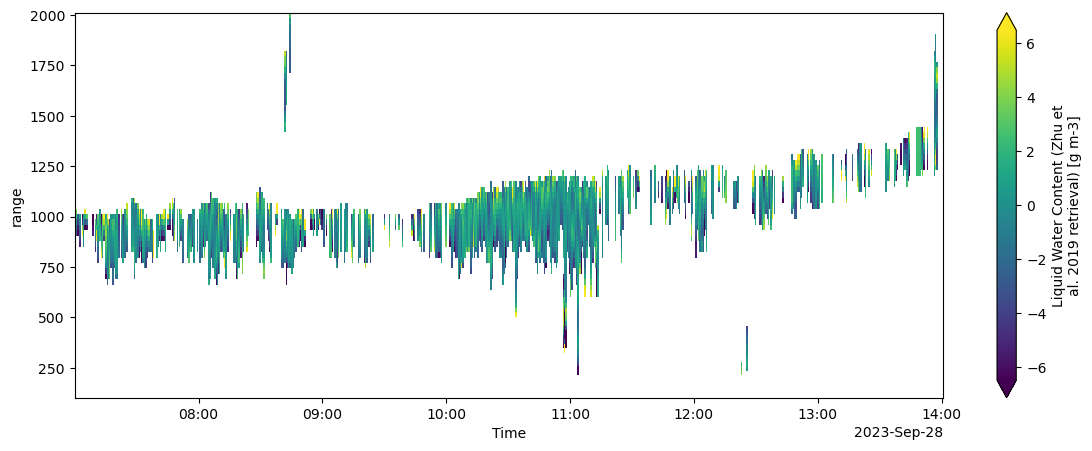

In [61]:
print(lwc)

lwc.plot(
    x="Time",
    y="range",
    figsize=(14, 5),
    cmap="viridis",
    robust=True,
)

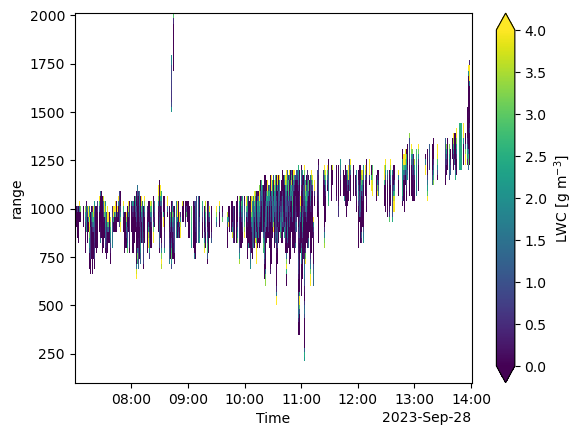

In [62]:
lwc.plot(
    x="Time",
    y="range",
    cmap="viridis",
    vmin=0,
    vmax=4,
    cbar_kwargs={"label": "LWC [g m$^{-3}$]"}
)

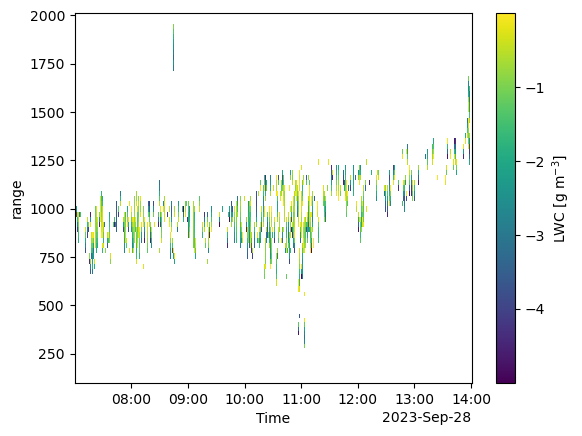

In [63]:
lwc_filtered = lwc.where((lwc >= -5) & (lwc <= 0))
lwc_filtered.plot(
    x="Time",
    y="range",
    cmap="viridis",
    cbar_kwargs={"label": "LWC [g m$^{-3}$]"}
)

In [161]:
print(f"Fraction LWC < 0: "
      f"{float((lwc < 0).sum() / lwc.notnull().sum()):.2%}")
print(f"LWC quantiles: "
      f"p05={float(lwc.quantile(0.05)):.2f}, "
      f"p50={float(lwc.quantile(0.5)):.2f}, "
      f"p95={float(lwc.quantile(0.95)):.2f} g/m³")


Fraction LWC < 0: 47.56%
LWC quantiles: p05=-4.22, p50=0.11, p95=4.25 g/m³


LWP

In [83]:
# Height spacing between radar gates (m)
dz = float(ds["range"].sel(range=slice(0, 2000)).diff("range").mean())
print(f"Gate spacing = {dz:.1f} m")
# Integrate LWC over height
lwp = (lwc * dz).sum(dim="range") /1000

lwp.name = "LWP"
lwp.attrs["units"] = "kg m^-2"

Gate spacing = 25.8 m


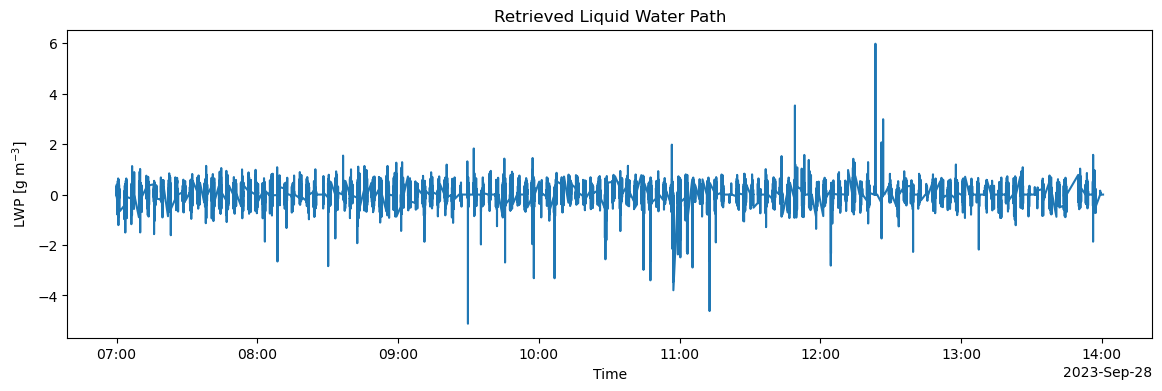

In [66]:
fig, ax = plt.subplots(figsize=(14, 4))

lwp.plot(ax=ax)

ax.set_title("Retrieved Liquid Water Path")
ax.set_ylabel("LWP [g m$^{-3}$]")
ax.set_xlabel("Time")

plt.show()

=================================================

dDWR_dH

=================================================

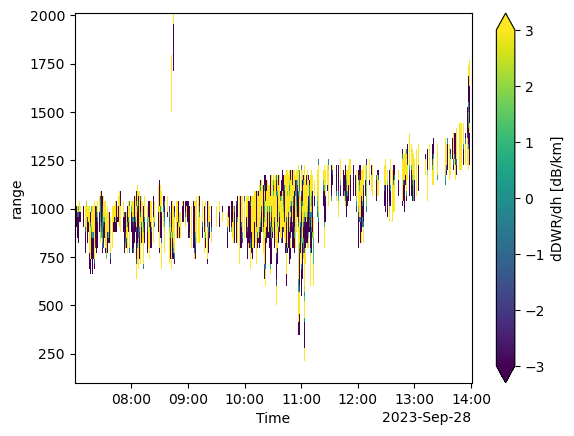

In [67]:
derivative.plot(
    x="Time",
    y="range",
    cmap="viridis",
    vmin=-3,
    vmax=3,
    cbar_kwargs={"label": "dDWR/dh [dB/km]"}
)

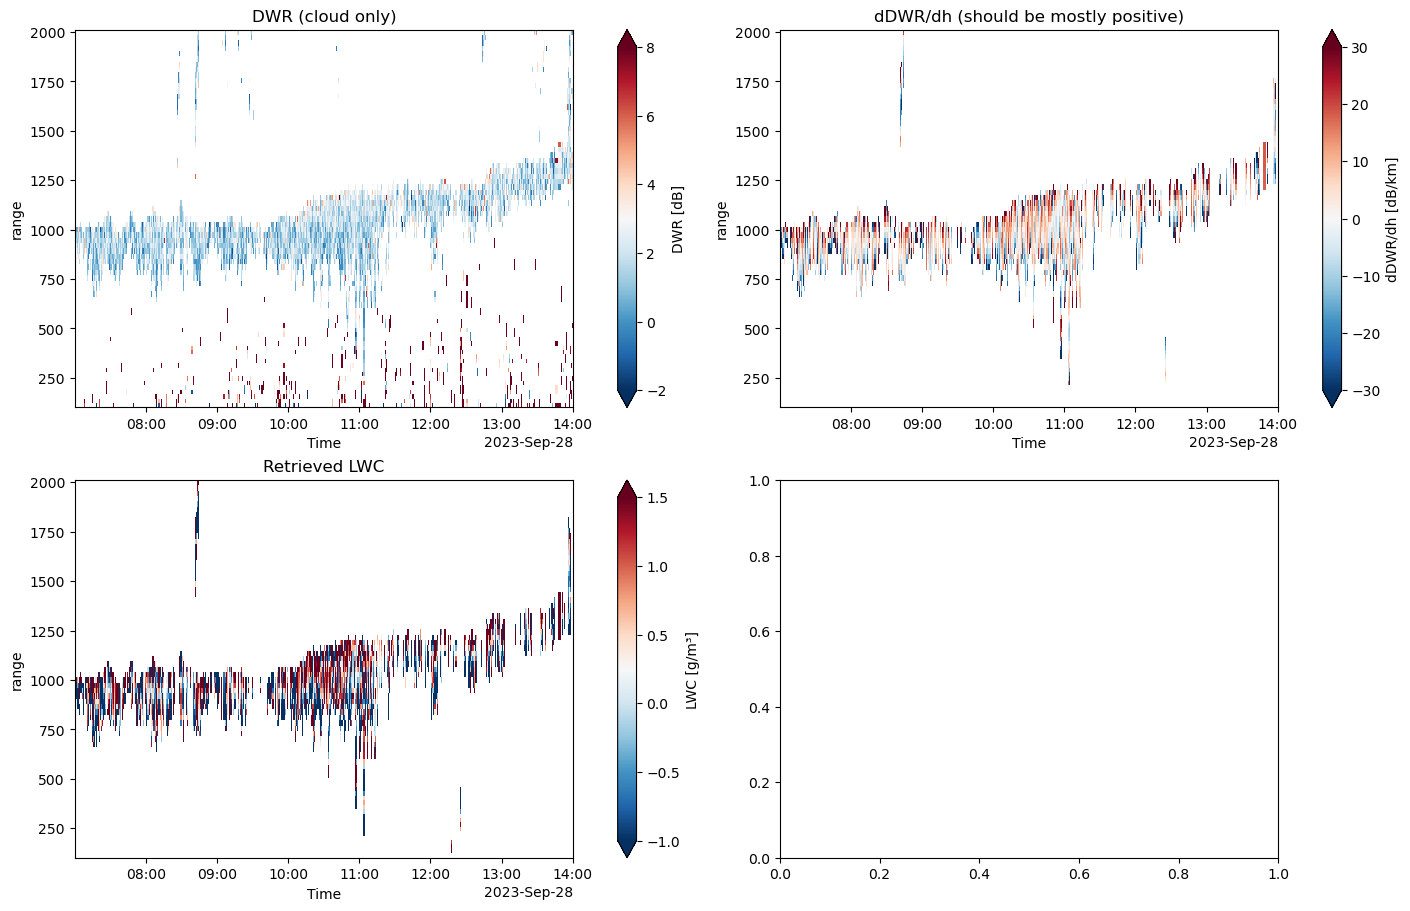

In [68]:
# %% Four diagnostic panels
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 9), constrained_layout=True)

# Panel 1: DWR in cloud
dwr_2km.where(cloud_mask_2km).plot(
    x="Time", y="range", ax=axes[0, 0],
    vmin=-2, vmax=8, cmap="RdBu_r",
    cbar_kwargs={"label": "DWR [dB]"})
axes[0, 0].set_title("DWR (cloud only)")

# Panel 2: dDWR/dh in cloud
derivative.where(cloud_mask_2km).plot(
    x="Time", y="range", ax=axes[0, 1],
    vmin=-30, vmax=30, cmap="RdBu_r",
    cbar_kwargs={"label": "dDWR/dh [dB/km]"})
axes[0, 1].set_title("dDWR/dh (should be mostly positive)")

# Panel 3: LWC in cloud (your existing retrieval)
lwc.where(cloud_mask_2km).plot(
    x="Time", y="range", ax=axes[1, 0],
    vmin=-1, vmax=1.5, cmap="RdBu_r",
    cbar_kwargs={"label": "LWC [g/m³]"})
axes[1, 0].set_title("Retrieved LWC")


plt.show()


=================================================

EXTRAS AND TEMPORAL AVERAGING OVER TIME TO REDUCE PERCENTAGE OF DDWR/DH <0 AND DDWR/DH >30

=================================================

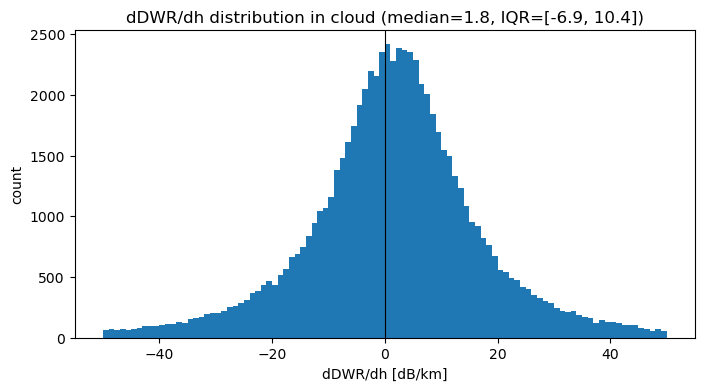

Fraction of gates with dDWR/dh < 0:   44.17%
Fraction with |dDWR/dh| > 30 dB/km:   9.81%


In [69]:
# %% Histogram of dDWR/dh in cloud
fig, ax = plt.subplots(figsize=(8, 4))
vals = derivative.where(cloud_mask_2km).values.ravel()
vals = vals[np.isfinite(vals)]
ax.hist(vals, bins=100, range=(-50, 50))
ax.axvline(0, color="k", lw=0.8)
ax.set_xlabel("dDWR/dh [dB/km]")
ax.set_ylabel("count")
ax.set_title(f"dDWR/dh distribution in cloud "
             f"(median={np.median(vals):.1f}, "
             f"IQR=[{np.percentile(vals,25):.1f}, {np.percentile(vals,75):.1f}])")
plt.show()

print(f"Fraction of gates with dDWR/dh < 0:   {(vals < 0).mean():.2%}")
print(f"Fraction with |dDWR/dh| > 30 dB/km:   {(np.abs(vals) > 30).mean():.2%}")


In [ ]:
# %% Estimate DWR noise per gate inside cloud
# Compare each in-cloud gate to its two vertical neighbours.
D = dwr_2km.where(cloud_mask_2km).values              # Only true Mask Values taken (in NumPy)
diffs = D[:, 1:] - D[:, :-1]                # gate-to-gate DWR differences ; delta_DWR= DWR_i+1 - DWR_i    ;D[:, 1:] is all times and all ranges from 1 onwards and D[:, :-1] is all times and all ranges from 0 to second last. Both are subtracted from each other to see the DWR difference
diffs = diffs[np.isfinite(diffs)]             # Remove NaN values from diffs array
noise_estimate = np.std(diffs) / np.sqrt(2)  # per-gate DWR noise;     Better Explanation in OneNote Programmieren/dual_freq_radar/Notebooks 03;  If DWR is seen as constant between neighbours, the difference between the measurements Y and X is just the difference between the noise of the two gates eps_1 and eps_2. 
# Var(Y-X) = Var(eps_1 - eps_2) =[Covariance between noise is 0]--> Var(eps_1) + Var(eps_2) = 2 * Var(eps) ;   So, std(Y-X) = sqrt(2) * std(eps) ;   So, std(eps) = std(Y-X)/sqrt(2)   std (sigma) is standard deviation and Var (sigma^2) is Variance
print(f"Estimated per-gate DWR noise: {noise_estimate:.2f} dB")
print(f"Median in-cloud DWR:          {float(dwr_2km.where(cloud_mask_2km).median()):.2f} dB")
print(f"Signal across a 9-gate (~200 m) window at 5 dB/km: {5 * 0.2:.2f} dB")    # Comparison Noise and Signal across  Window


Estimated per-gate DWR noise: 0.99 dB
Median in-cloud DWR:          1.80 dB
Signal across a 9-gate (~200 m) window at 5 dB/km: 1.00 dB


dDWR/dH FUNCTION

In [146]:
import numpy as np
import xarray as xr

def compute_ddwr_dh(
    dwr: xr.DataArray,              # (time, range) [dB]
    cloud_mask: xr.DataArray,       # (time, range) bool
    N_default: int = 9,             # window size (gates)
    min_cloud_gates: int = 3,       # skip profiles with fewer than this
) -> xr.DataArray:
    """
    Same Algorithm as Zhu
    """

    # ── Pull NumPy views for speed ───────────────────────────────────────────
    r_m = dwr["range"].values.astype(float)      # heights [m]
    n_t, n_r = dwr.shape

    dwr_v = dwr.values
    mask_v = cloud_mask.values.astype(bool)

    # ── Output accumulators ──────────────────────────────────────────────────
    derivative_sum = np.zeros((n_t, n_r), dtype=float)
    derivative_count = np.zeros((n_t, n_r), dtype=int)

    # ── Outer loop: time step by time step ───────────────────────────────────
    for t in range(n_t):

        # ── Find cloud gates at this time step ───────────────────────────────
        cloud_idx = np.where(mask_v[t])[0]       # indices where cloud_mask is True

        if cloud_idx.size < min_cloud_gates:
            continue

        i_base = cloud_idx.min()
        i_top = cloud_idx.max()
        thickness = i_top - i_base + 1

        # ── Adapt window size for thin clouds ────────────────────────────────
        N = min(N_default, thickness)

        if N < 3:
            continue

        # ── Slide window from cloud base to cloud top ────────────────────────
        for i_start in range(i_base, i_top - N + 2):

            i_end = i_start + N

            h_win = r_m[i_start:i_end]
            dwr_win = dwr_v[t, i_start:i_end]
            mask_win = mask_v[t, i_start:i_end]

            # Require all gates in the window to be cloud
            if not mask_win.all():
                continue

            # Skip windows containing NaN or Inf
            if np.any(~np.isfinite(dwr_win)):
                continue

            # ── Fit quadratic & compute analytical derivative ────────────────
            # DWR(h) ≈ a·h² + b·h + c
            # dDWR/dh = 2ah + b

            a, b, _ = np.polyfit(h_win, dwr_win, 2)

            dDWR_dh_per_m = 2.0 * a * h_win + b
            dDWR_dh = dDWR_dh_per_m * 1000.0      # dB/km

            # ── Accumulate derivative estimates ──────────────────────────────
            idx = np.arange(i_start, i_end)

            derivative_sum[t, idx] += dDWR_dh
            derivative_count[t, idx] += 1

    # ── Average contributions from overlapping windows ──────────────────────
    with np.errstate(invalid="ignore", divide="ignore"):
        derivative = np.where(
            derivative_count > 0,
            derivative_sum / derivative_count,
            np.nan,
        )

    # ── Wrap into xarray ─────────────────────────────────────────────────────
    derivative_da = xr.DataArray(
        derivative,
        dims=dwr.dims,
        coords=dwr.coords,
        name="dDWR_dh",
        attrs={
            "units": "dB km-1",
            "long_name": "Vertical derivative of DWR",
            "method": "Sliding-window quadratic fit",
            "window_size_default_gates": N_default,
            "min_cloud_gates": min_cloud_gates,
        },
    )

    return derivative_da

ddwr_dh = compute_ddwr_dh(dwr, cloud_mask, N_default=9)


In [147]:
# %% Time-averaged DWR — the SNR lever
# CRUCIAL: average in linear (mm^6/m^3), not dB.
def avg_ze_time(ze_db, window_s=30):
    """Average dBZ in linear units over a time window."""
    z_lin = 10.0 ** (ze_db / 10.0)          # Make Reflectivity Linear again

    # xarray rolling on the Time dim; center=True keeps the same time axis
    # Convert 'window_s' to a rolling count using the median dt
    dt = float(np.median(np.diff(ze_db["Time"].values).astype("timedelta64[s]").astype(float)))    #median time between "Time".values of the reflectivity data array in seconds (as float)
    n = max(1, int(round(window_s / dt)))         # Window size divided by average time step gives the number of time steps to include in the rolling average
    z_avg = z_lin.rolling(Time=n, center=True, min_periods=1).mean()      # Takes middle point( center=True) of the rolling window and computes the mean of the linear reflectivity values in that window. min_periods=1 means that if there is at least one valid value in the window, it will compute the mean; otherwise, it will return NaN.
                                               #min_periods=1: Compute an average as long as there is at least one valid value in the window. At the beginning and end of the time series, the average is then calculated from the available values only
                                                # min_periods=n: Compute an average only if the full window of n values is available. Otherwise, the result is NaN.
    return 10.0 * np.log10(z_avg)

ze_ka_avg = avg_ze_time(ds["Ze_Ka"].sel(range=slice(0, 2000)), window_s=30)
ze_w_avg  = avg_ze_time(ds["Ze_W"].sel(range=slice(0, 2000)),  window_s=30)

dwr_2km_smoothed = ze_ka_avg - ze_w_avg
dwr_2km_smoothed.name = "DWR"

# Re-run the diagnostic
ddwr_dh_smoothed = compute_ddwr_dh(dwr_2km_smoothed, cloud_mask_2km, N_default=9)

vals = ddwr_dh_smoothed.where(cloud_mask_2km).values.ravel()
vals = vals[np.isfinite(vals)]
print(f"After 30 s time-averaging:")
print(f"  Fraction dDWR/dh < 0:            {(vals < 0).mean():.2%}")
print(f"  Fraction |dDWR/dh| > 30 dB/km:   {(np.abs(vals) > 30).mean():.2%}")
print(f"  median dDWR/dh:                  {np.median(vals):.2f} dB/km")


After 30 s time-averaging:
  Fraction dDWR/dh < 0:            30.62%
  Fraction |dDWR/dh| > 30 dB/km:   2.69%
  median dDWR/dh:                  1.99 dB/km


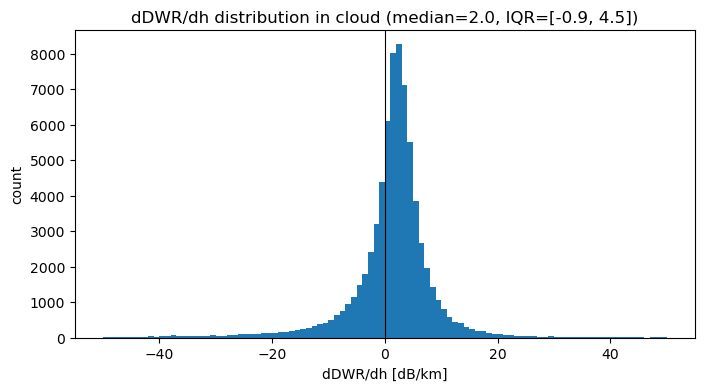

Fraction of gates with dDWR/dh < 0:   30.62%
Fraction with |dDWR/dh| > 30 dB/km:   2.69%


In [148]:
# %% Histogram of dDWR/dh in cloud
fig, ax = plt.subplots(figsize=(8, 4))
vals = ddwr_dh_smoothed.where(cloud_mask_2km).values.ravel()
vals = vals[np.isfinite(vals)]
ax.hist(vals, bins=100, range=(-50, 50))
ax.axvline(0, color="k", lw=0.8)
ax.set_xlabel("dDWR/dh [dB/km]")
ax.set_ylabel("count")
ax.set_title(f"dDWR/dh distribution in cloud "
             f"(median={np.median(vals):.1f}, "
             f"IQR=[{np.percentile(vals,25):.1f}, {np.percentile(vals,75):.1f}])")
plt.show()

print(f"Fraction of gates with dDWR/dh < 0:   {(vals < 0).mean():.2%}")
print(f"Fraction with |dDWR/dh| > 30 dB/km:   {(np.abs(vals) > 30).mean():.2%}")

In [149]:
lwc_2, derivative_2 = retrieve_lwc_zhu(
    dwr=dwr_2km_smoothed,
    kappa_w=kappa_w_2km,
    kappa_ka=kappa_ka_2km,
    alpha_w=alpha_w_2km,
    alpha_ka=alpha_ka_2km,
    cloud_mask=cloud_mask_2km,
    N_default=9,
    min_cloud_gates=3,
)

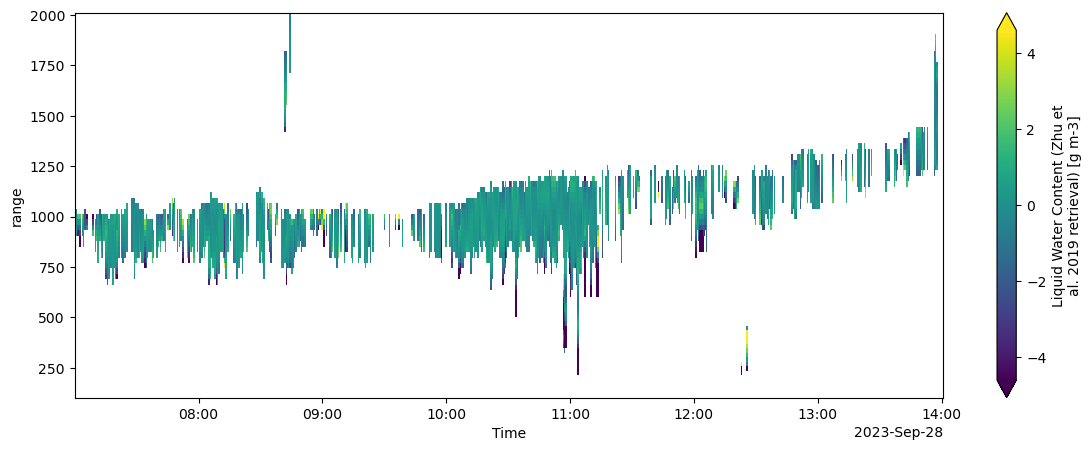

In [150]:


lwc_2.plot(
    x="Time",
    y="range",
    figsize=(14, 5),
    cmap="viridis",
    robust=True,
)

In [ ]:
print(f"Fraction LWC < 0: "
      f"{float((lwc_2 < 0).sum() / lwc_2.notnull().sum()):.2%}")
print(f"LWC quantiles: "
      f"p05={float(lwc_2.quantile(0.05)):.2f}, "
      f"p50={float(lwc_2.quantile(0.5)):.2f}, "
      f"p95={float(lwc_2.quantile(0.95)):.2f} g/m³")


Fraction LWC < 0: 39.25%
LWC quantiles: p05=-2.11, p50=0.14, p95=1.41 g/m³


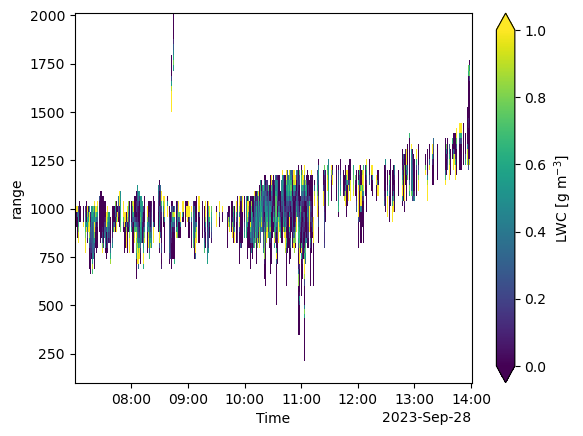

In [151]:
lwc_2.plot(
    x="Time",
    y="range",
    cmap="viridis",
    vmin=0,
    vmax=1,
    cbar_kwargs={"label": "LWC [g m$^{-3}$]"}
)

In [152]:
# %% Estimate DWR noise per gate inside cloud
# Compare each in-cloud gate to its two vertical neighbours.
D = dwr_2km_smoothed.where(cloud_mask_2km).values              # Only true Mask Values taken (in NumPy)
diffs = D[:, 1:] - D[:, :-1]                # gate-to-gate DWR differences ; delta_DWR= DWR_i+1 - DWR_i    ;D[:, 1:] is all times and all ranges from 1 onwards and D[:, :-1] is all times and all ranges from 0 to second last. Both are subtracted from each other to see the DWR difference
diffs = diffs[np.isfinite(diffs)]             # Remove NaN values from diffs array
noise_estimate = np.std(diffs) / np.sqrt(2)  # per-gate DWR noise
print(f"Estimated per-gate DWR noise: {noise_estimate:.2f} dB")
print(f"Median in-cloud DWR:          {float(dwr_2km_smoothed.where(cloud_mask_2km).median()):.2f} dB")
print(f"Signal across a 9-gate (~200 m) window at 5 dB/km: {5 * 0.20:.2f} dB")    # Comparison Noise and Signal across  Window


Estimated per-gate DWR noise: 0.76 dB
Median in-cloud DWR:          1.67 dB
Signal across a 9-gate (~200 m) window at 5 dB/km: 1.00 dB


===================================================================================================================================================================================

SAME CODE BUT FOR 60s. SMALL IMPROVEMENT ONLY

===================================================================================================================================================================================

In [153]:
# %% Time-averaged DWR — the SNR lever
# CRUCIAL: average in linear (mm^6/m^3), not dB.
def avg_ze_time(ze_db, window_s=30):
    """Average dBZ in linear units over a time window."""
    z_lin = 10.0 ** (ze_db / 10.0)
    # xarray rolling on the Time dim; center=True keeps the same time axis
    # Convert 'window_s' to a rolling count using the median dt
    dt = float(np.median(np.diff(ze_db["Time"].values).astype("timedelta64[s]").astype(float)))
    n = max(1, int(round(window_s / dt)))
    z_avg = z_lin.rolling(Time=n, center=True, min_periods=1).mean()
    return 10.0 * np.log10(z_avg)

ze_ka_avg = avg_ze_time(ds["Ze_Ka"].sel(range=slice(0, 2000)), window_s=60)
ze_w_avg  = avg_ze_time(ds["Ze_W"].sel(range=slice(0, 2000)),  window_s=60)

dwr_2km_smoothed_60 = ze_ka_avg - ze_w_avg
dwr_2km_smoothed_60.name = "DWR"

# Re-run the diagnostic
ddwr_dh_smoothed_60 = compute_ddwr_dh(dwr_2km_smoothed_60, cloud_mask_2km, N_default=9)

vals = ddwr_dh_smoothed_60.where(cloud_mask_2km).values.ravel()
vals = vals[np.isfinite(vals)]
print(f"After 60 s time-averaging:")
print(f"  Fraction dDWR/dh < 0:            {(vals < 0).mean():.2%}")
print(f"  Fraction |dDWR/dh| > 30 dB/km:   {(np.abs(vals) > 30).mean():.2%}")
print(f"  median dDWR/dh:                  {np.median(vals):.2f} dB/km")

After 60 s time-averaging:
  Fraction dDWR/dh < 0:            28.49%
  Fraction |dDWR/dh| > 30 dB/km:   2.60%
  median dDWR/dh:                  2.15 dB/km


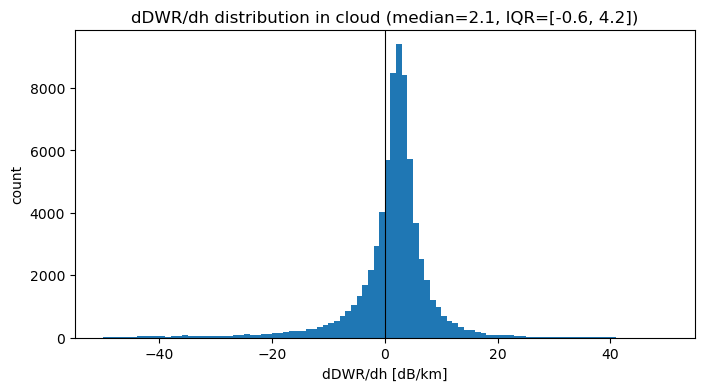

Fraction of gates with dDWR/dh < 0:   28.49%
Fraction with |dDWR/dh| > 30 dB/km:   2.60%


In [154]:
# %% Histogram of dDWR/dh in cloud
fig, ax = plt.subplots(figsize=(8, 4))
vals = ddwr_dh_smoothed_60.where(cloud_mask_2km).values.ravel()
vals = vals[np.isfinite(vals)]
ax.hist(vals, bins=100, range=(-50, 50))
ax.axvline(0, color="k", lw=0.8)
ax.set_xlabel("dDWR/dh [dB/km]")
ax.set_ylabel("count")
ax.set_title(f"dDWR/dh distribution in cloud "
             f"(median={np.median(vals):.1f}, "
             f"IQR=[{np.percentile(vals,25):.1f}, {np.percentile(vals,75):.1f}])")
plt.show()

print(f"Fraction of gates with dDWR/dh < 0:   {(vals < 0).mean():.2%}")
print(f"Fraction with |dDWR/dh| > 30 dB/km:   {(np.abs(vals) > 30).mean():.2%}")

In [155]:
lwc_60, derivative_60 = retrieve_lwc_zhu(
    dwr=dwr_2km_smoothed_60,
    kappa_w=kappa_w_2km,
    kappa_ka=kappa_ka_2km,
    alpha_w=alpha_w_2km,
    alpha_ka=alpha_ka_2km,
    cloud_mask=cloud_mask_2km,
    N_default=9,
    min_cloud_gates=3,
)

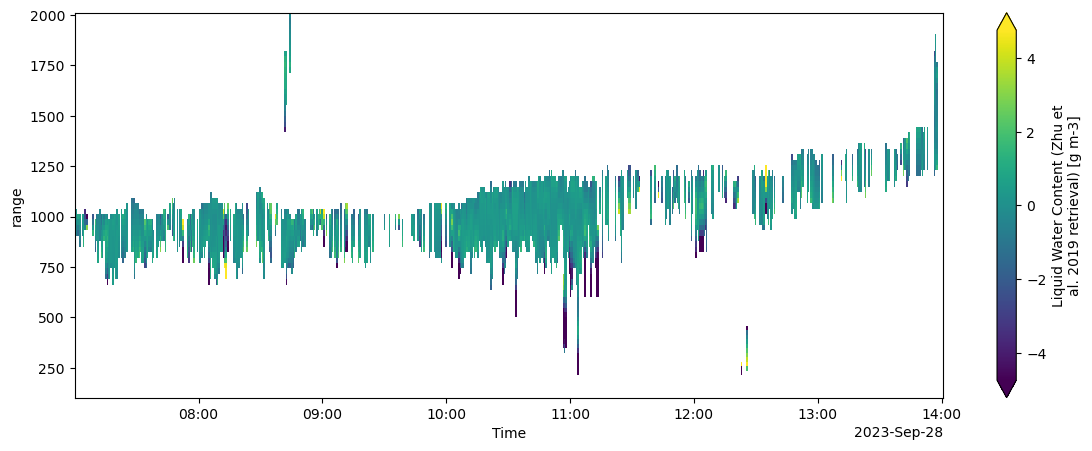

In [156]:


lwc_60.plot(
    x="Time",
    y="range",
    figsize=(14, 5),
    cmap="viridis",
    robust=True,
)

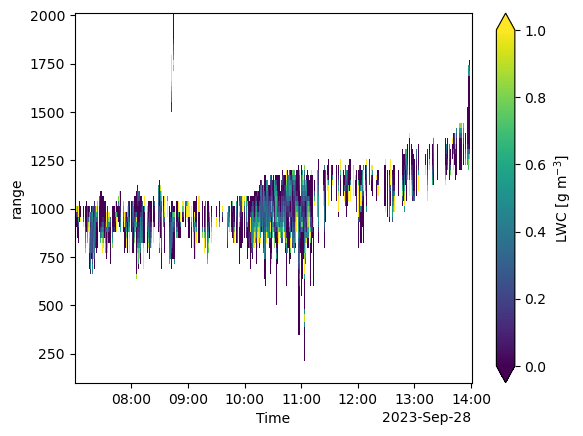

In [157]:
lwc_60.plot(
    x="Time",
    y="range",
    cmap="viridis",
    vmin=0,
    vmax=1,
    cbar_kwargs={"label": "LWC [g m$^{-3}$]"}
)

In [160]:

print(f"Fraction LWC < 0: "
      f"{float((lwc_60 < 0).sum() / lwc_60.notnull().sum()):.2%}")
print(f"LWC quantiles: "
      f"p05={float(lwc_60.quantile(0.05)):.2f}, "
      f"p50={float(lwc_60.quantile(0.5)):.2f}, "
      f"p95={float(lwc_60.quantile(0.95)):.2f} g/m³")


Fraction LWC < 0: 36.55%
LWC quantiles: p05=-2.13, p50=0.16, p95=1.34 g/m³


In [158]:
# %% Estimate DWR noise per gate inside cloud
# Compare each in-cloud gate to its two vertical neighbours.
D = dwr_2km_smoothed_60.where(cloud_mask_2km).values              # Only true Mask Values taken (in NumPy)
diffs = D[:, 1:] - D[:, :-1]                # gate-to-gate DWR differences ; delta_DWR= DWR_i+1 - DWR_i    ;D[:, 1:] is all times and all ranges from 1 onwards and D[:, :-1] is all times and all ranges from 0 to second last. Both are subtracted from each other to see the DWR difference
diffs = diffs[np.isfinite(diffs)]             # Remove NaN values from diffs array
noise_estimate = np.std(diffs) / np.sqrt(2)  # per-gate DWR noise
print(f"Estimated per-gate DWR noise: {noise_estimate:.2f} dB")
print(f"Median in-cloud DWR:          {float(dwr_2km_smoothed_60.where(cloud_mask_2km).median()):.2f} dB")
print(f"Signal across a 9-gate (~200 m) window at 5 dB/km: {5 * 0.20:.2f} dB")    # Comparison Noise and Signal across  Window


Estimated per-gate DWR noise: 0.68 dB
Median in-cloud DWR:          1.63 dB
Signal across a 9-gate (~200 m) window at 5 dB/km: 1.00 dB


MASKING